In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [4]:
df = pd.read_csv('../data/kenya_solar_data.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nSolar radiation statistics (MJ/m²/day):")
print(df['avg_radiation'].describe().round(2))
print(f"\nFirst 5 rows:")
df.head()

Shape: (47, 8)

Column types:
county            object
region            object
latitude         float64
longitude        float64
avg_radiation    float64
max_radiation    float64
min_radiation    float64
data_points        int64
dtype: object

Solar radiation statistics (MJ/m²/day):
count    47.00
mean     21.86
std       0.81
min      20.25
25%      21.33
50%      21.83
75%      22.23
max      23.67
Name: avg_radiation, dtype: float64

First 5 rows:


,county,region,latitude,longitude,avg_radiation,max_radiation,min_radiation,data_points
0,Nairobi,Nairobi,-1.2921,36.8219,21.408,28.88,10.25,365
1,Mombasa,Coast,-4.0435,39.6682,20.901,26.32,3.64,365
2,Kwale,Coast,-4.1816,39.4524,20.247,26.43,4.38,365
3,Kilifi,Coast,-3.5107,39.9093,21.333,26.43,2.24,365
4,Tana River,Coast,-1.0116,39.9093,21.014,26.76,2.45,365


In [5]:
print("TOP 10 COUNTIES — HIGHEST SOLAR POTENTIAL")
print("-"*45)
top10 = df.nlargest(10, 'avg_radiation')[['county', 'region', 'avg_radiation']]
for _, row in top10.iterrows():
    bar = '█' * int(row['avg_radiation'] / 1.5)
    print(f"{row['county']:<20} {bar} {row['avg_radiation']:.2f} MJ/m²/day")

print("\n BOTTOM 10 COUNTIES — LOWEST SOLAR POTENTIAL")
print("-"*45)
bottom10 = df.nsmallest(10, 'avg_radiation')[['county', 'region', 'avg_radiation']]
for _, row in bottom10.iterrows():
    bar = '█' * int(row['avg_radiation'] / 1.5)
    print(f"{row['county']:<20} {bar} {row['avg_radiation']:.2f} MJ/m²/day")

TOP 10 COUNTIES — HIGHEST SOLAR POTENTIAL
---------------------------------------------
Elgeyo Marakwet      ███████████████ 23.67 MJ/m²/day
Uasin Gishu          ███████████████ 23.65 MJ/m²/day
Baringo              ███████████████ 23.38 MJ/m²/day
Turkana              ███████████████ 23.20 MJ/m²/day
Isiolo               ███████████████ 23.09 MJ/m²/day
Laikipia             ███████████████ 23.06 MJ/m²/day
Kisumu               ███████████████ 23.01 MJ/m²/day
Samburu              ███████████████ 22.75 MJ/m²/day
Nakuru               ███████████████ 22.73 MJ/m²/day
Bomet                ██████████████ 22.30 MJ/m²/day

 BOTTOM 10 COUNTIES — LOWEST SOLAR POTENTIAL
---------------------------------------------
Kwale                █████████████ 20.25 MJ/m²/day
Kirinyaga            █████████████ 20.59 MJ/m²/day
Embu                 █████████████ 20.63 MJ/m²/day
Taita Taveta         █████████████ 20.88 MJ/m²/day
Mombasa              █████████████ 20.90 MJ/m²/day
Wajir                █████████████ 2

In [6]:
# ── SOLAR POTENTIAL SCORING MODEL ────────────────────────────
# We score each county on 3 factors:
# 1. Average radiation (60% weight) — most important
# 2. Consistency — low variation between min and max (30% weight)
# 3. Peak radiation — maximum radiation achieved (10% weight)

# Factor 1 — Normalize average radiation (0 to 1 scale)
df['avg_score'] = (df['avg_radiation'] - df['avg_radiation'].min()) / \
                  (df['avg_radiation'].max() - df['avg_radiation'].min())

# Factor 2 — Consistency score
# Lower variation = more consistent = better for solar planning
df['variation'] = df['max_radiation'] - df['min_radiation']
df['consistency_score'] = 1 - ((df['variation'] - df['variation'].min()) / \
                               (df['variation'].max() - df['variation'].min()))

# Factor 3 — Normalize peak radiation (0 to 1 scale)
df['peak_score'] = (df['max_radiation'] - df['max_radiation'].min()) / \
                   (df['max_radiation'].max() - df['max_radiation'].min())

# ── COMBINE INTO FINAL SCORE ──────────────────────────────────
df['solar_score'] = (df['avg_score'] * 0.60 + 
                     df['consistency_score'] * 0.30 + 
                     df['peak_score'] * 0.10)

# Scale to 0-100 for readability
df['solar_score'] = (df['solar_score'] * 100).round(1)

# ── ASSIGN PRIORITY TIER ──────────────────────────────────────
def assign_tier(score):
    if score >= 70:
        return 'Tier 1 — High Priority'
    elif score >= 50:
        return 'Tier 2 — Medium Priority'
    else:
        return 'Tier 3 — Low Priority'

df['priority_tier'] = df['solar_score'].apply(assign_tier)

# Preview results
result = df[['county', 'region', 'avg_radiation', 'solar_score', 'priority_tier']]
result = result.sort_values('solar_score', ascending=False)
print(result.to_string(index=False))


         county        region  avg_radiation  solar_score            priority_tier
    Uasin Gishu   Rift Valley         23.652         83.3   Tier 1 — High Priority
        Turkana   Rift Valley         23.205         83.2   Tier 1 — High Priority
        Baringo   Rift Valley         23.381         81.3   Tier 1 — High Priority
Elgeyo Marakwet   Rift Valley         23.670         81.2   Tier 1 — High Priority
         Nakuru   Rift Valley         22.730         73.2   Tier 1 — High Priority
         Kisumu        Nyanza         23.007         71.9   Tier 1 — High Priority
       Laikipia   Rift Valley         23.056         67.3 Tier 2 — Medium Priority
         Isiolo       Eastern         23.093         65.1 Tier 2 — Medium Priority
          Narok   Rift Valley         22.231         63.6 Tier 2 — Medium Priority
          Bomet   Rift Valley         22.304         62.3 Tier 2 — Medium Priority
    Trans Nzoia   Rift Valley         22.298         62.2 Tier 2 — Medium Priority
    

In [7]:
tier_counts = df['priority_tier'].value_counts()
print("SOLAR PRIORITY TIER DISTRIBUTION")
print("-"*40)
for tier, count in tier_counts.items():
    print(f"{tier}: {count} counties")

print(f"\nTier 1 counties:")
tier1 = df[df['priority_tier'] == 'Tier 1 — High Priority'][['county', 'region', 'solar_score']]
tier1 = tier1.sort_values('solar_score', ascending=False)
print(tier1.to_string(index=False))

SOLAR PRIORITY TIER DISTRIBUTION
----------------------------------------
Tier 3 — Low Priority: 24 counties
Tier 2 — Medium Priority: 17 counties
Tier 1 — High Priority: 6 counties

Tier 1 counties:
         county      region  solar_score
    Uasin Gishu Rift Valley         83.3
        Turkana Rift Valley         83.2
        Baringo Rift Valley         81.3
Elgeyo Marakwet Rift Valley         81.2
         Nakuru Rift Valley         73.2
         Kisumu      Nyanza         71.9


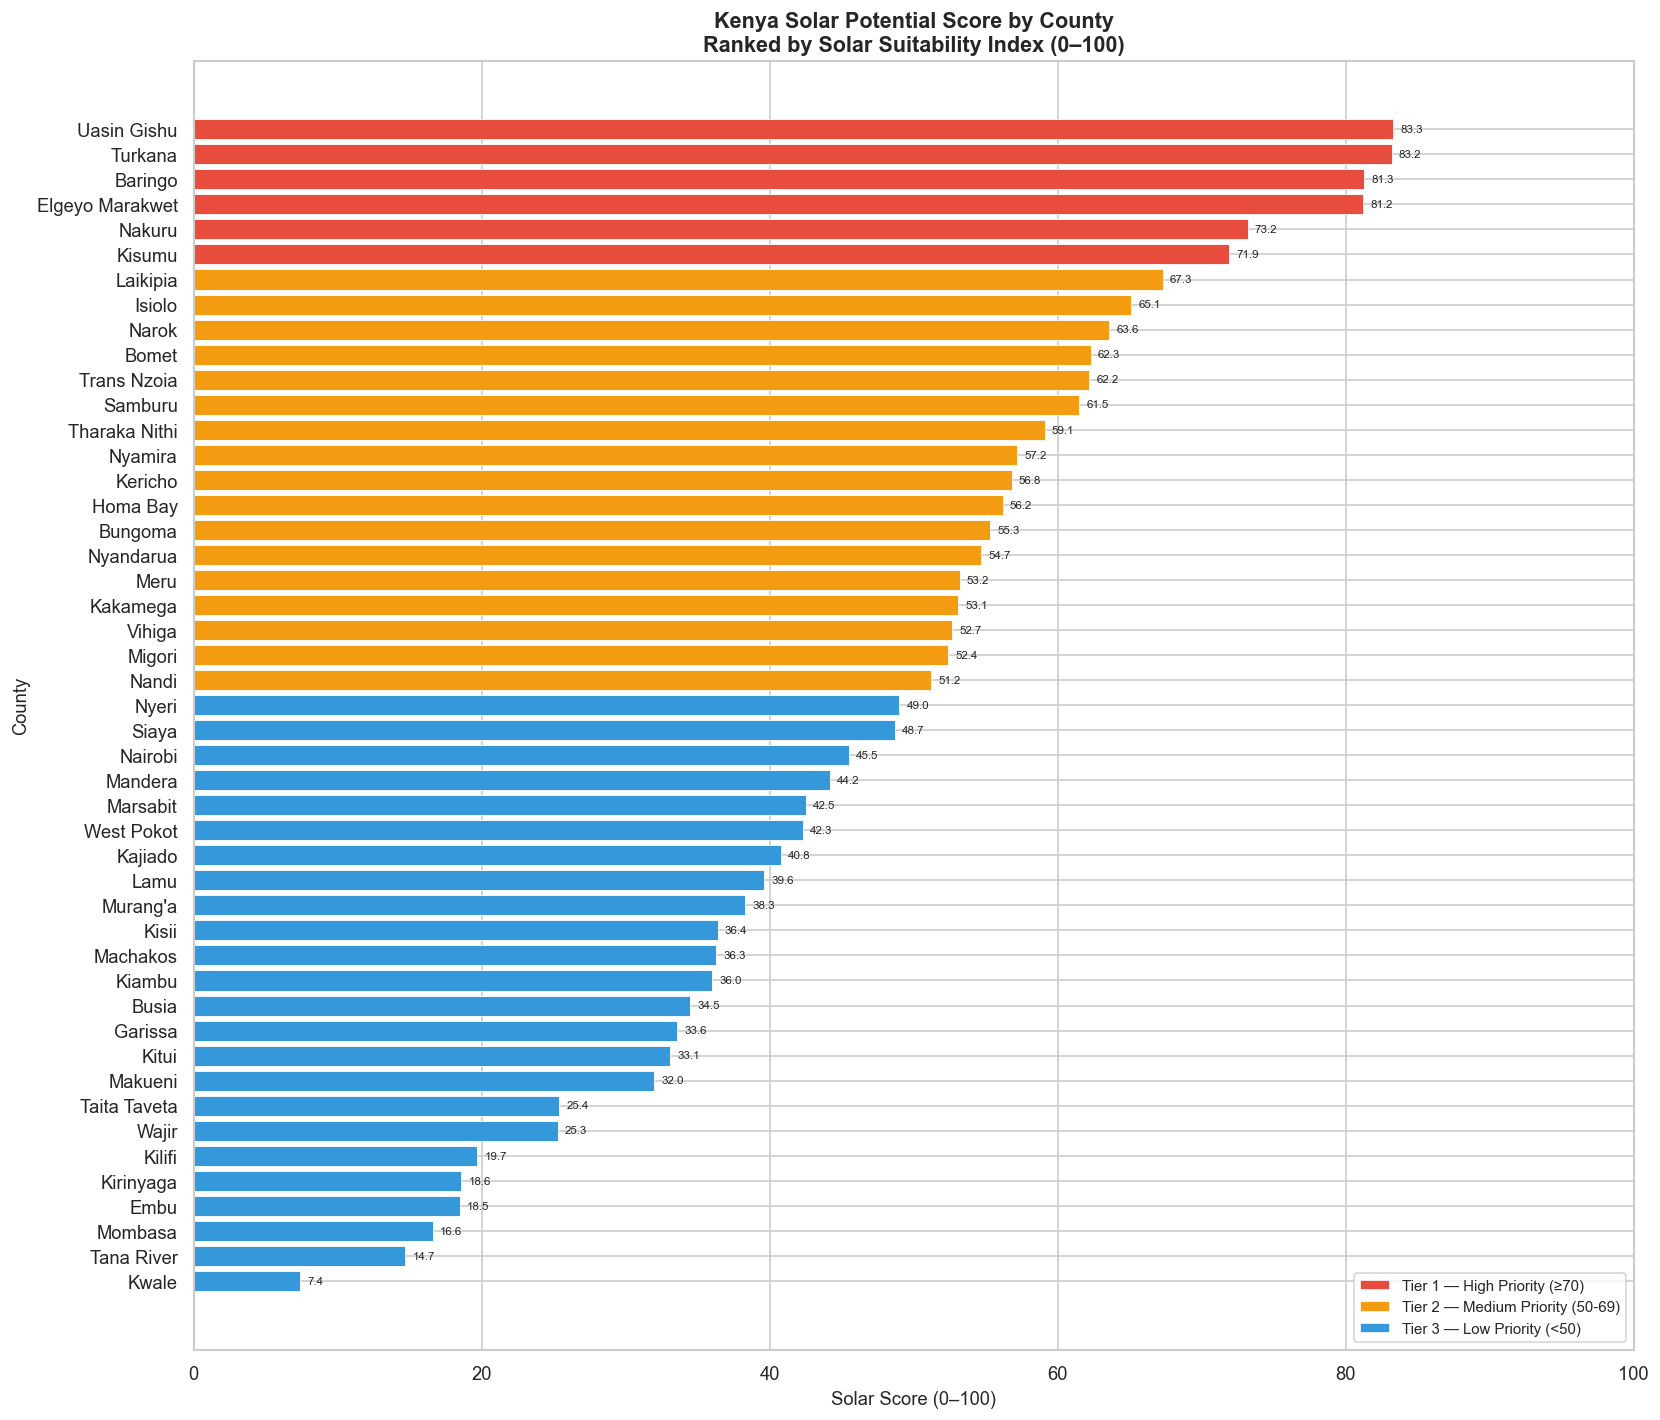

In [8]:
plt.figure(figsize=(14, 12))

# Sort by solar score
df_sorted = df.sort_values('solar_score', ascending=True)

# Color by tier
tier_colors = {
    'Tier 1 — High Priority': '#e74c3c',
    'Tier 2 — Medium Priority': '#f39c12',
    'Tier 3 — Low Priority': '#3498db'
}
colors = [tier_colors[tier] for tier in df_sorted['priority_tier']]

bars = plt.barh(df_sorted['county'],
                df_sorted['solar_score'],
                color=colors,
                edgecolor='white',
                linewidth=0.5)

# Add score labels
for bar, score in zip(bars, df_sorted['solar_score']):
    plt.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f'{score:.1f}',
             va='center', fontsize=7)

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', label='Tier 1 — High Priority (≥70)'),
    mpatches.Patch(facecolor='#f39c12', label='Tier 2 — Medium Priority (50-69)'),
    mpatches.Patch(facecolor='#3498db', label='Tier 3 — Low Priority (<50)')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.title('Kenya Solar Potential Score by County\nRanked by Solar Suitability Index (0–100)',
          fontsize=13, fontweight='bold')
plt.xlabel('Solar Score (0–100)', fontsize=11)
plt.ylabel('County', fontsize=11)
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig('../data/solar_scores_ranked.png', dpi=150)
plt.show()

In [11]:
# Load level 1
kenya = gpd.read_file('../data/kenya_shapefile/gadm41_KEN_1.shp')

print(f"Shapefile shape: {kenya.shape}")
print(f"\nColumns: {list(kenya.columns)}")
print(f"\nCounty names:")
print(kenya['NAME_1'].values)

Shapefile shape: (47, 12)

Columns: ['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']

County names:
['Baringo' 'Bomet' 'Bungoma' 'Busia' 'Elgeyo-Marakwet' 'Embu' 'Garissa'
 'Homa Bay' 'Isiolo' 'Kajiado' 'Kakamega' 'Kericho' 'Kiambu' 'Kilifi'
 'Kirinyaga' 'Kisii' 'Kisumu' 'Kitui' 'Kwale' 'Laikipia' 'Lamu' 'Machakos'
 'Makueni' 'Mandera' 'Marsabit' 'Meru' 'Migori' 'Mombasa' "Murang'a"
 'Nairobi' 'Nakuru' 'Nandi' 'Narok' 'Nyamira' 'Nyandarua' 'Nyeri'
 'Samburu' 'Siaya' 'Taita Taveta' 'Tana River' 'Tharaka-Nithi'
 'Trans Nzoia' 'Turkana' 'Uasin Gishu' 'Vihiga' 'Wajir' 'West Pokot']


In [12]:
# Fix county name mismatches
name_fixes = {
    'Elgeyo-Marakwet': 'Elgeyo Marakwet',
    'Tharaka-Nithi': 'Tharaka Nithi',
    'Murang\'a': "Murang'a"
}

kenya['NAME_1'] = kenya['NAME_1'].replace(name_fixes)

# Merge shapefile with solar data
merged = kenya.merge(df, 
                     left_on='NAME_1', 
                     right_on='county', 
                     how='left')

# Check merge result
print(f"Merged shape: {merged.shape}")
print(f"\nCounties with missing solar data:")
print(merged[merged['solar_score'].isna()]['NAME_1'].values)

Merged shape: (47, 26)

Counties with missing solar data:
[]


C:\Users\user\AppData\Local\Temp\ipykernel_15656\683571056.py:53: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[1].legend(loc='lower left', fontsize=8)
C:\Users\user\AppData\Local\Temp\ipykernel_15656\683571056.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='lower left', fontsize=8)


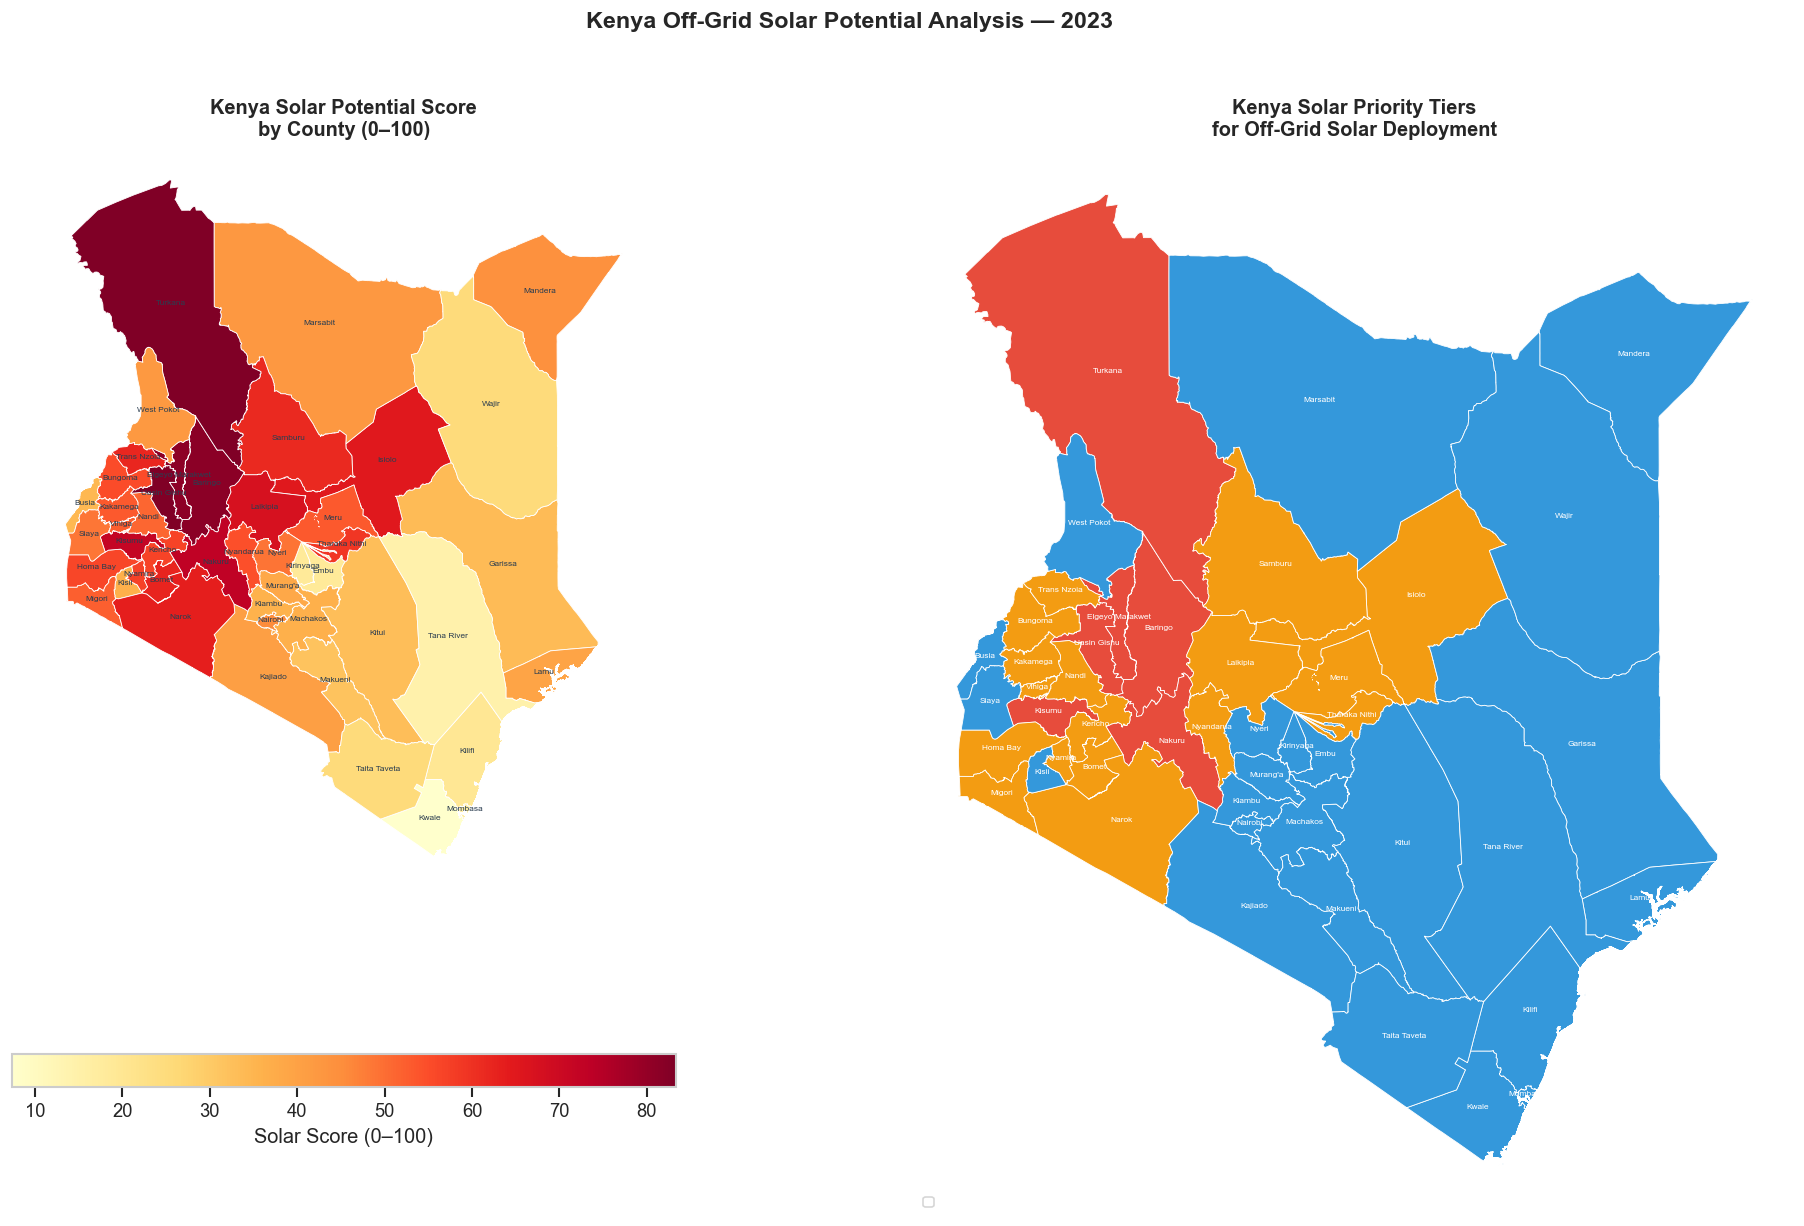

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# ── LEFT MAP — Solar Score ────────────────────────────────────
merged.plot(column='solar_score',
            cmap='YlOrRd',
            linewidth=0.5,
            edgecolor='white',
            legend=True,
            legend_kwds={'label': 'Solar Score (0–100)',
                        'orientation': 'horizontal',
                        'shrink': 0.6},
            ax=axes[0])

# Add county name labels
for _, row in merged.iterrows():
    centroid = row['geometry'].centroid
    axes[0].annotate(row['NAME_1'],
                    xy=(centroid.x, centroid.y),
                    fontsize=5,
                    ha='center',
                    color='#2c3e50')

axes[0].set_title('Kenya Solar Potential Score\nby County (0–100)',
                  fontsize=12, fontweight='bold')
axes[0].set_axis_off()

# ── RIGHT MAP — Priority Tiers ────────────────────────────────
tier_colors = {
    'Tier 1 — High Priority': '#e74c3c',
    'Tier 2 — Medium Priority': '#f39c12',
    'Tier 3 — Low Priority': '#3498db'
}

for tier, color in tier_colors.items():
    subset = merged[merged['priority_tier'] == tier]
    subset.plot(ax=axes[1],
               color=color,
               linewidth=0.5,
               edgecolor='white',
               label=tier)

# Add county name labels
for _, row in merged.iterrows():
    centroid = row['geometry'].centroid
    axes[1].annotate(row['NAME_1'],
                    xy=(centroid.x, centroid.y),
                    fontsize=5,
                    ha='center',
                    color='white')

axes[1].set_title('Kenya Solar Priority Tiers\nfor Off-Grid Solar Deployment',
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=8)
axes[1].set_axis_off()

plt.suptitle('Kenya Off-Grid Solar Potential Analysis — 2023',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/kenya_solar_map_proper.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Average solar score by region
regional = df.groupby('region').agg(
    avg_score=('solar_score', 'mean'),
    best_county=('county', lambda x: x.loc[df.loc[x.index, 'solar_score'].idxmax()]),
    county_count=('county', 'count')
).round(1).sort_values('avg_score', ascending=False)

print("SOLAR POTENTIAL BY REGION")
print("-"*50)
print(regional.to_string())

SOLAR POTENTIAL BY REGION
--------------------------------------------------
               avg_score  best_county  county_count
region                                             
Rift Valley         65.0  Uasin Gishu            14
Nyanza              53.8       Kisumu             6
Western             48.9      Bungoma             4
Nairobi             45.5      Nairobi             1
Eastern             42.5       Isiolo             8
Central             39.3    Nyandarua             5
North Eastern       34.4      Mandera             3
Coast               20.6         Lamu             6


In [15]:
print("=" * 55)
print("KENYA SOLAR POTENTIAL ANALYSIS — KEY FINDINGS")
print("=" * 55)

tier1 = df[df['priority_tier'] == 'Tier 1 — High Priority'].sort_values('solar_score', ascending=False)
tier2 = df[df['priority_tier'] == 'Tier 2 — Medium Priority'].sort_values('solar_score', ascending=False)
tier3 = df[df['priority_tier'] == 'Tier 3 — Low Priority'].sort_values('solar_score', ascending=False)

print(f"""
DATASET
-------
Counties analyzed:  {len(df)}
Data source:        Open-Meteo API (2023)
Solar metric:       Shortwave radiation (MJ/m²/day)

NATIONAL OVERVIEW
-----------------
Average solar score:    {df['solar_score'].mean():.1f}/100
Highest scoring county: {df.loc[df['solar_score'].idxmax(), 'county']} ({df['solar_score'].max():.1f})
Lowest scoring county:  {df.loc[df['solar_score'].idxmin(), 'county']} ({df['solar_score'].min():.1f})

PRIORITY TIERS
--------------
Tier 1 — High Priority ({len(tier1)} counties):
{', '.join(tier1['county'].values)}

Tier 2 — Medium Priority ({len(tier2)} counties):
{', '.join(tier2['county'].values)}

Tier 3 — Low Priority ({len(tier3)} counties):
{', '.join(tier3['county'].values)}

REGIONAL RANKING
----------------
1. Rift Valley — highest avg solar score
2. Eastern — strong potential in arid areas
3. North Eastern — high radiation, low consistency
4. Central — moderate, affected by highland cloud cover
5. Nyanza — moderate, lake Victoria microclimate
6. Western — lower radiation, high rainfall
7. Coast — lowest, high humidity reduces irradiance
8. Nairobi — urban, moderate

NGO DEPLOYMENT RECOMMENDATION
------------------------------
Priority 1: Turkana, Uasin Gishu, Baringo
            (High score + large off-grid population)
Priority 2: Elgeyo Marakwet, Nakuru, Kisumu
            (High score + accessible terrain)
Avoid first: Kwale, Mombasa, Coast counties
             (Low solar score + grid already present)
""")
print("=" * 55)


KENYA SOLAR POTENTIAL ANALYSIS — KEY FINDINGS

DATASET
-------
Counties analyzed:  47
Data source:        Open-Meteo API (2023)
Solar metric:       Shortwave radiation (MJ/m²/day)

NATIONAL OVERVIEW
-----------------
Average solar score:    47.6/100
Highest scoring county: Uasin Gishu (83.3)
Lowest scoring county:  Kwale (7.4)

PRIORITY TIERS
--------------
Tier 1 — High Priority (6 counties):
Uasin Gishu, Turkana, Baringo, Elgeyo Marakwet, Nakuru, Kisumu

Tier 2 — Medium Priority (17 counties):
Laikipia, Isiolo, Narok, Bomet, Trans Nzoia, Samburu, Tharaka Nithi, Nyamira, Kericho, Homa Bay, Bungoma, Nyandarua, Meru, Kakamega, Vihiga, Migori, Nandi

Tier 3 — Low Priority (24 counties):
Nyeri, Siaya, Nairobi, Mandera, Marsabit, West Pokot, Kajiado, Lamu, Murang'a, Kisii, Machakos, Kiambu, Busia, Garissa, Kitui, Makueni, Taita Taveta, Wajir, Kilifi, Kirinyaga, Embu, Mombasa, Tana River, Kwale

REGIONAL RANKING
----------------
1. Rift Valley — highest avg solar score
2. Eastern — strong p